In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression 
from pypfopt import risk_models, EfficientFrontier, expected_returns
import yfinance as yf

In [1]:
# !pip install yfinance==0.2.47

In [2]:
risk_free_rate = 0.065  # Risk free rate

In [3]:
# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # For saving and loading models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Ensure the models directory exists
if not os.path.exists("models"):
    os.makedirs("models")

# %%
# --- PART 1: FUNCTIONS FOR FEATURE ENGINEERING AND TARGET COMPUTATION ---

def compute_features(df, window_5=5, window_10=10, momentum_lag=3):
    """
    Computes six features from closing prices.
      - Return: Daily percentage change.
      - MA_5: 5-day moving average.
      - MA_10: 10-day moving average.
      - Volatility_5: Standard deviation of daily returns over 5 days.
      - Momentum: Difference between current Close and Close from 'momentum_lag' days ago.
      - Ratio_Close_MA5: Current close divided by its 5-day moving average.
    """
    df = df.copy()
    df['Return'] = df['Close'].pct_change()
    df['MA_5'] = df['Close'].rolling(window=window_5).mean()
    df['MA_10'] = df['Close'].rolling(window=window_10).mean()
    df['Volatility_5'] = df['Return'].rolling(window=window_5).std()
    df['Momentum'] = df['Close'] - df['Close'].shift(momentum_lag)
    df['Ratio_Close_MA5'] = df['Close'] / df['MA_5']
    
    # Drop rows with insufficient data
    df = df.dropna()
    return df

def compute_target(df, horizon=3):
    """
    Computes the 3-day lookahead return as the target:
       Target = (Close_{t+horizon} / Close_t) - 1
    """
    df = df.copy()
    df['Target'] = df['Close'].shift(-horizon) / df['Close'] - 1
    df = df.dropna()
    return df


# %%
# --- PART 2: TRAINING MODELS FOR EACH STOCK (2015-2018) ---

# Load closing price data.
# The CSV should have a datetime index and columns for each asset's closing price.
prices = pd.read_excel('PX_LAST_Static.xlsx', index_col=0)
mcap = pd.read_excel('CUR_MKT_CAP_Static.xlsx', index_col=0)
prices.index = pd.to_datetime(prices.index)
mcap.index = pd.to_datetime(mcap.index)

# Define your assets (assume each column is an asset).
assets = list(prices.columns)

# Training period: 2015-01-01 to 2018-12-31
train_start = pd.to_datetime("2015-01-01")
train_end   = pd.to_datetime("2018-12-31")

# Define the features to be used.
features = ['Return', 'MA_5', 'MA_10', 'Volatility_5', 'Momentum', 'Ratio_Close_MA5']

# For each asset, train a linear regression model.
for asset in assets:
    # Prepare data for the asset
    asset_df = prices[[asset]].loc[train_start:train_end].copy()
    asset_df = asset_df.sort_index()
    asset_df.rename(columns={asset: "Close"}, inplace=True)
    
    # Compute features and target.
    df_features = compute_features(asset_df)
    df_features = compute_target(df_features, horizon=3)
    
    # Check that we have enough samples.
    if df_features.empty:
        print(f"Not enough data to train model for {asset}.")
        continue

    # Extract X and y (using raw features, without scaling).
    X = df_features[features].values
    y = df_features['Target'].values
    
    # Train linear regression model.
    lr_model = LinearRegression()
    lr_model.fit(X, y)
    
    # Save the trained model.
    model_name = asset
    joblib.dump(lr_model, f"lr_models/{model_name}.pkl")
    
    print(f"Trained and saved model for {asset}: {model_name}")


# %%
# --- PART 3: BACKTEST FUNCTION USING THE TRAINED MODELS FOR BLACK-LITTERMAN ---

# Note: The following backtest function assumes that:
#   - `data` is a DataFrame of closing prices for all assets (with a DateTime index),
#   - `mcap` is a DataFrame of market capitalizations with the same index,
#   - `risk_models.sample_cov` computes the covariance matrix from price data,
#   - `black_litterman.market_implied_risk_aversion` and `black_litterman.market_implied_prior_returns`
#       are available functions, and
#   - A BlackLittermanModel class is implemented.
#   - The `strategy` function for portfolio optimization (e.g. max sharpe) is provided.
#
# Please ensure these are imported or defined in your working environment.


# %%
# Example usage:
# For the backtest, you must have:
#   - `data`: a DataFrame of closing prices for all assets (same as the 'prices' DataFrame),
#   - `mcap`: a DataFrame of market capitalizations,
#   - a portfolio optimization strategy function (e.g., strategy maximizing Sharpe ratio),
#   - risk_models and black_litterman modules and BlackLittermanModel class.
#
# Example call:



Trained and saved model for ABB IS Equity: ABB IS Equity
Trained and saved model for ABFRL IS Equity: ABFRL IS Equity
Trained and saved model for ACC IS Equity: ACC IS Equity
Trained and saved model for ACEM IS Equity: ACEM IS Equity
Trained and saved model for ADANI IS Equity: ADANI IS Equity
Trained and saved model for ADE IS Equity: ADE IS Equity
Trained and saved model for ADSEZ IS Equity: ADSEZ IS Equity
Trained and saved model for AL IS Equity: AL IS Equity
Trained and saved model for APAT IS Equity: APAT IS Equity
Trained and saved model for APHS IS Equity: APHS IS Equity
Trained and saved model for APNT IS Equity: APNT IS Equity
Trained and saved model for APTY IS Equity: APTY IS Equity
Trained and saved model for ARBP IS Equity: ARBP IS Equity
Trained and saved model for ASTRA IS Equity: ASTRA IS Equity
Trained and saved model for AXSB IS Equity: AXSB IS Equity
Trained and saved model for BAF IS Equity: BAF IS Equity
Trained and saved model for BHARTI IS Equity: BHARTI IS Equi

In [4]:
# mcap = pd.read_csv("mcap.csv", index_col=0)
# 

# data = pd.read_csv('prices.csv', index_col=0)
# data.index = pd.to_datetime(data.index)

data = pd.read_excel('PX_LAST_Static.xlsx', index_col=0)
data.index = pd.to_datetime(data.index)
mcap = pd.read_excel('CUR_MKT_CAP_Static.xlsx', index_col=0)
mcap.index = pd.to_datetime(mcap.index)

In [5]:
import scipy.optimize as sco  # Import scipy.optimize as sco

def min_volatility_weights(mu, S):
    ef = EfficientFrontier(mu, S, weight_bounds=(0.0, 0.5))
    ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    return cleaned_weights


def max_sharpe_ratio(mu, S):

    num_assets = len(mu)

    def sharpe_ratio(weights):
        weights = np.array(weights)
        port_return = np.dot(weights, mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(S, weights)))
        risk_free_rate = 0
        return -(port_return - risk_free_rate) / port_volatility  # Negative for minimization

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Sum of weights must be 1
    bounds = tuple((0.0,0.50) for _ in range(num_assets))  # No short selling
    initial_weights = np.ones(num_assets) / num_assets  # Equal allocation start

    result = sco.minimize(sharpe_ratio, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints, options={'disp': False, 'maxiter': 1000})

    optimal_weights = result.x
    cleaned_weights = {asset: weight for asset, weight in zip(data.columns, optimal_weights)}
    return cleaned_weights

import cvxpy as cp
def MVO(bl_returns, bl_cov):
    # Convert bl_returns to a NumPy array to ensure compatibility with cvxpy
    bl_returns = bl_returns.to_numpy()
    
    n = len(bl_returns)
    w = cp.Variable(n)

    # Objective function: w^T mu - lambda * w^T S w
    lambda_val = 3  # Risk aversion parameter (balanced approach)
    portfolio_return = bl_returns @ w  # Now using matrix multiplication with NumPy array
    portfolio_variance = cp.quad_form(w, bl_cov)
    objective = cp.Maximize(portfolio_return - lambda_val * portfolio_variance)

    # Constraints
    constraints = [
        cp.sum(w) == 1,  # Weights sum to 1
        w >= 0.01,
        w <= 0.40,  # Long-only constraint
            # Long-only constraint
    ]

    # Step 2: Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Step 3: Extract the optimal weights
    optimal_weights = w.value
    if optimal_weights is None:
        raise ValueError("Optimization failed to find a solution.")

    optimal_weights = np.round(optimal_weights, decimals=4)
    optimal_weights = np.maximum(optimal_weights, 0)

    weights_dict = dict(zip(assets, optimal_weights))
    return weights_dict


In [128]:
# %%
import os
import numpy as np
import pandas as pd
import joblib
import warnings
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")

from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt import risk_models, expected_returns
from pypfopt.efficient_frontier import EfficientFrontier

# %% 
# Example portfolio strategy function: minimum volatility weights.
def min_volatility_weights(mu, S):
    ef = EfficientFrontier(mu, S, weight_bounds=(0.0, 0.5))
    ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    return cleaned_weights

# %% 
# Helper function to generate a model name from asset ticker and model version.
def get_model_name(asset, model_number):
    return f"{asset}_{model_number}"

# %% 
# Compute raw features from closing prices.
def compute_features(df, window_5=5, window_10=10, momentum_lag=3):
    """
    Computes six features from closing prices:
      - Return: Daily percentage change.
      - MA_5: 5-day moving average.
      - MA_10: 10-day moving average.
      - Volatility_5: Standard deviation of daily returns over 5 days.
      - Momentum: Difference between current Close and Close from 'momentum_lag' days ago.
      - Ratio_Close_MA5: Close divided by its 5-day moving average.
    """
    df = df.copy()
    df['Return'] = df['Close'].pct_change()
    df['MA_5'] = df['Close'].rolling(window=window_5).mean()
    df['MA_10'] = df['Close'].rolling(window=window_10).mean()
    df['Volatility_5'] = df['Return'].rolling(window=window_5).std()
    df['Momentum'] = df['Close'] - df['Close'].shift(momentum_lag)
    df['Ratio_Close_MA5'] = df['Close'] / df['MA_5']
    df = df.dropna()
    return df

# Function to compute the 3-day lookahead target return.
def compute_target(df, horizon=3):
    """
    Computes the 3-day lookahead return as:
         Target = (Close_{t+horizon} / Close_t) - 1
    """
    df = df.copy()
    df['Target'] = df['Close'].shift(-horizon) / df['Close'] - 1
    df = df.dropna()
    return df

# %% 
# Backtest function using a fixed set of models that are updated after each iteration.
def backtest(strategy):
    # Define backtest start and end dates.
    start_date = pd.to_datetime("2018-01-08")
    end_date = pd.to_datetime("2025-01-08")
    
    # Equal initial weights for all assets.
    initial_weights = {ticker: 1/len(assets) for ticker in assets}
    
    # Get market caps at start_date (ensure that mcap DataFrame is aligned with your price data).
    mcaps_dict = mcap.loc[start_date].to_dict()
    
    initial_investment = 100  # Starting portfolio value
    portfolio_value = [initial_investment]
    dates = [start_date]
    
    # Set the initial model version and load initial models.
    model_number = 0  
    model_dict = {}
    for asset in assets:
        model_name = asset
        try:
            model = joblib.load(f"lr_models/{model_name}.pkl")
            # Since we are not using scaling, we simply store the model.
            model_dict[asset] = model
        except Exception as e:
            print(f"Error loading model for {asset}: {e}")
    
    rebalance_frequency = 5  # Rebalance every 3 days.
    transaction_cost_rate = 0.004  # 0.4% transaction cost
    
    last_rebalance_date = start_date
    previous_weights = None
    current_date = start_date

    # Backtesting loop: iterate through dates until end_date.
    while current_date < end_date:
        # -------------------------
        # Prediction Step:
        # -------------------------
        Q = {}  # Expected return views dictionary for Black–Litterman.
        for stock_name, model in model_dict.items():
            # Get available closing prices up to current_date.
            asset_series = data[stock_name].loc[:current_date]
            if asset_series.empty or len(asset_series) < 15:
                continue  # Skip if insufficient data.
            # Form a DataFrame and compute features.
            df_asset = pd.DataFrame({'Close': asset_series})
            df_feat = compute_features(df_asset)
            if df_feat.empty:
                continue
            # Use the latest computed features.
            latest_features = df_feat.iloc[-1][features].values.reshape(1, -1)
            # Predict the 3-day lookahead return.
            predicted_return = model.predict(latest_features)[0]
            # Optionally, adjust (annualize) the prediction.
            # This adjustment factor is as in your sample code; modify as needed.
            adjusted_return = predicted_return * (252/3) * (1/15)
            Q[stock_name] = adjusted_return

        # -------------------------
        # Build Black–Litterman Model:
        # -------------------------
        viewdict = Q
        S = risk_models.sample_cov(data.loc[:current_date])
        delta = black_litterman.market_implied_risk_aversion(data.loc[:current_date])
        prior = black_litterman.market_implied_prior_returns(mcaps_dict, delta, S)
        bl = BlackLittermanModel(S, pi=prior, absolute_views=viewdict)
        bl_returns = bl.bl_returns()
        bl_cov = bl.bl_cov()
        
        # -------------------------
        # Portfolio Optimization:
        # -------------------------
        cleaned_weights = strategy(bl_returns, bl_cov)
        
        # -------------------------
        # Rebalancing Logic:
        # -------------------------
        should_rebalance = False
        days_since_rebalance = (current_date - last_rebalance_date).days
        if days_since_rebalance >= rebalance_frequency:
            should_rebalance = True
        if previous_weights is not None:
            weight_diff = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0))
                              for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
            if weight_diff >= 0.6:
                should_rebalance = True
        
        if should_rebalance:
            # Record weights.
            previous_weights = cleaned_weights.copy()
            last_rebalance_date = current_date
            
            # Determine the next rebalance date.
            curr_date_index = data.index.get_loc(current_date)
            next_index = min(curr_date_index + rebalance_frequency, len(data) - 1)
            next_date = data.index[next_index]
            
            # Compute returns over the rebalance period.
            actual_returns = data.loc[current_date:next_date].pct_change().dropna()
            weights_series = pd.Series(cleaned_weights)
            portfolio_returns = (actual_returns @ weights_series).values
            
            transaction_cost = 0
            if len(portfolio_value) > 0 and previous_weights is not None:
                turnover = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0))
                               for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
                transaction_cost = portfolio_value[-1] * turnover * transaction_cost_rate

            for j in range(len(portfolio_returns)):
                new_value = portfolio_value[-1] * (1 + portfolio_returns[j])
                if j == 0 and transaction_cost > 0:
                    new_value -= transaction_cost
                portfolio_value.append(new_value)
                dates.append(actual_returns.index[j])
            
            print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
            current_date = next_date
        else:
            curr_date_index = data.index.get_loc(current_date)
            current_date = data.index[min(curr_date_index + 1, len(data) - 1)]
        
        # -------------------------
        # Model Update: Append new data and retrain.
        # -------------------------
        for asset in assets:
            asset_series = data[asset].loc[:current_date]
            if asset_series.empty or len(asset_series) < 15:
                continue
            df_train = pd.DataFrame({'Close': asset_series})
            df_train_feat = compute_features(df_train)
            df_train_feat = compute_target(df_train_feat, horizon=3)
            if df_train_feat.empty:
                continue
            X_train = df_train_feat[features].values
            y_train = df_train_feat['Target'].values
            new_model = LinearRegression()
            new_model.fit(X_train, y_train)
            model_dict[asset] = new_model

    print(f"Final portfolio value: {portfolio_value[-1]}")
    return portfolio_value, dates, cleaned_weights

# %% 
# Example usage:
# Ensure that these variables exist in your environment:
#   - data: DataFrame of closing prices for each asset (indexed by date).
#   - mcap: DataFrame of market capitalizations.
#   - assets: List of asset tickers corresponding to the columns of data.
#   - features: List of feature names, e.g.,
#               ['Return', 'MA_5', 'MA_10', 'Volatility_5', 'Momentum', 'Ratio_Close_MA5']
#
# Then run the backtest with your chosen strategy function:
# portfolio_vals, date_series, weights_history = backtest(min_volatility_weights)


In [90]:
final_value, date_series, weight_history = backtest(min_volatility_weights)

Portfolio value at 2018-01-22 00:00:00: 101.27990905107755
Portfolio value at 2018-01-30 00:00:00: 100.46930945288618
Portfolio value at 2018-02-06 00:00:00: 96.82352890745422
Portfolio value at 2018-02-14 00:00:00: 98.370033113285
Portfolio value at 2018-02-21 00:00:00: 97.28269621000622
Portfolio value at 2018-02-28 00:00:00: 98.16857929207569
Portfolio value at 2018-03-08 00:00:00: 96.08991311709724
Portfolio value at 2018-03-15 00:00:00: 97.3070598142494
Portfolio value at 2018-03-22 00:00:00: 95.47061022471209
Portfolio value at 2018-04-02 00:00:00: 97.43036155688883
Portfolio value at 2018-04-09 00:00:00: 98.78498837400376
Portfolio value at 2018-04-16 00:00:00: 100.46351178770487
Portfolio value at 2018-04-23 00:00:00: 102.71631228292348
Portfolio value at 2018-04-30 00:00:00: 104.69393051478112
Portfolio value at 2018-05-08 00:00:00: 102.88005567072452
Portfolio value at 2018-05-15 00:00:00: 103.92933314848842
Portfolio value at 2018-05-22 00:00:00: 104.17993655390475
Portfolio

Text(0.5, 1.0, 'Portfolio Value Over Time')

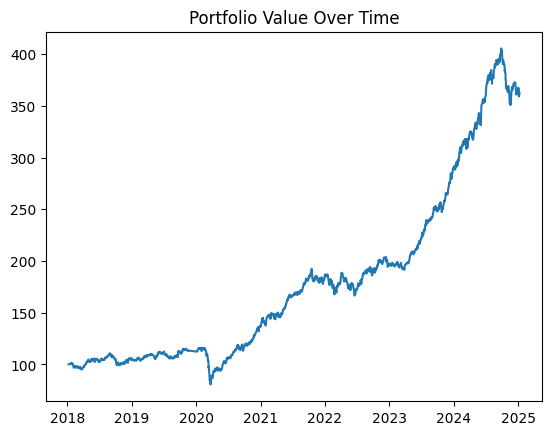

In [91]:
plt.plot(date_series, final_value)
plt.title("Portfolio Value Over Time")

In [96]:
# do it for all strategies
final_value1, date_series1, weight_history1 = backtest(max_sharpe_ratio)

Portfolio value at 2018-01-22 00:00:00: 101.6328356238933
Portfolio value at 2018-01-30 00:00:00: 102.17535211178401
Portfolio value at 2018-02-06 00:00:00: 96.8437385171332
Portfolio value at 2018-02-14 00:00:00: 97.65817647397944
Portfolio value at 2018-02-21 00:00:00: 96.07303044985174
Portfolio value at 2018-02-28 00:00:00: 97.78974568751792
Portfolio value at 2018-03-08 00:00:00: 95.259946609594
Portfolio value at 2018-03-15 00:00:00: 96.12735701862907
Portfolio value at 2018-03-22 00:00:00: 95.22641544142904
Portfolio value at 2018-04-02 00:00:00: 98.03889043405582
Portfolio value at 2018-04-09 00:00:00: 100.55837129229346
Portfolio value at 2018-04-16 00:00:00: 100.56577393461963
Portfolio value at 2018-04-23 00:00:00: 100.0780283547543
Portfolio value at 2018-04-30 00:00:00: 100.20867817463636
Portfolio value at 2018-05-08 00:00:00: 99.41049921904565
Portfolio value at 2018-05-15 00:00:00: 102.27593188345698
Portfolio value at 2018-05-22 00:00:00: 100.46848505599598
Portfolio v

In [113]:
# # plot weights history how they change over time
# plt.figure(figsize=(10, 6))
# # plt.plot(date_series, weight_history, label='Min Volatility', color='orange')
# plt.plot(date_series1, weight_history1, label='Max Sharpe Ratio', color='blue')



In [73]:
# plot weights history
#weights_df = pd.DataFrame(weight_history1, index=date_series)
# weights_df.plot(title="Weights History")
# plt.legend(loc='upper left')
plt.show()

In [6]:
import cvxpy as cp
def MVO(bl_returns, bl_cov):
    # Convert bl_returns to a NumPy array to ensure compatibility with cvxpy
    bl_returns = bl_returns.to_numpy()
    
    n = len(bl_returns)
    w = cp.Variable(n)

    # Objective function: w^T mu - lambda * w^T S w
    lambda_val = 2  # Risk aversion parameter (balanced approach)
    portfolio_return = bl_returns @ w  # Now using matrix multiplication with NumPy array
    portfolio_variance = cp.quad_form(w, bl_cov)
    objective = cp.Maximize(portfolio_return - lambda_val * portfolio_variance)

    # Constraints
    constraints = [
        cp.sum(w) == 1,  # Weights sum to 1
        w >= 0.005,
        w <= 0.40,  # Long-only constraint
            # Long-only constraint
    ]

    # Step 2: Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Step 3: Extract the optimal weights
    optimal_weights = w.value
    if optimal_weights is None:
        raise ValueError("Optimization failed to find a solution.")

    optimal_weights = np.round(optimal_weights, decimals=4)
    optimal_weights = np.maximum(optimal_weights, 0)

    weights_dict = dict(zip(assets, optimal_weights))
    return weights_dict

In [134]:
final_value2, date_series2, weight_history2 = backtest(MVO)  # Example with min volatility strategy

Portfolio value at 2018-01-22 00:00:00: 100.3722295688988
Portfolio value at 2018-01-30 00:00:00: 99.77351541760069
Portfolio value at 2018-02-06 00:00:00: 94.24494978888083
Portfolio value at 2018-02-14 00:00:00: 96.40491067619135
Portfolio value at 2018-02-21 00:00:00: 93.91745694301538
Portfolio value at 2018-02-28 00:00:00: 95.28909994914224
Portfolio value at 2018-03-08 00:00:00: 92.30827296992179
Portfolio value at 2018-03-15 00:00:00: 93.94421325942922
Portfolio value at 2018-03-22 00:00:00: 91.50117068398096
Portfolio value at 2018-04-02 00:00:00: 93.61433313709409
Portfolio value at 2018-04-09 00:00:00: 95.76296112660683
Portfolio value at 2018-04-16 00:00:00: 96.25274087044954
Portfolio value at 2018-04-23 00:00:00: 96.81359956122085
Portfolio value at 2018-04-30 00:00:00: 97.86708382860705
Portfolio value at 2018-05-08 00:00:00: 96.67044104742341
Portfolio value at 2018-05-15 00:00:00: 95.97067025009096
Portfolio value at 2018-05-22 00:00:00: 94.00358583174335
Portfolio valu

In [136]:
# save the results
import pickle
# with open('portfolio_results.pkl', 'wb') as f:
#     pickle.dump((final_value, date_series, weight_history), f)
# with open('portfolio_results1.pkl', 'wb') as f:
#     pickle.dump((final_value1, date_series1, weight_history1), f)
with open('portfolio_results2.pkl', 'wb') as f:
    pickle.dump((final_value2, date_series2, weight_history2), f)


In [ ]:
risk_free_rate = 0.065  # Risk free rate
def get_annualized_returns(portfolio_value):
    return (portfolio_value[-1] / portfolio_value[0]) ** (252 / len(portfolio_value)) - 1

def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown

def get_volatility(portfolio_value):
    return portfolio_value.pct_change().std() * np.sqrt(252)

def calculate_yearly_metrics(portfolio_values, dates):
    # Convert to DataFrame with dates as index
    df = pd.DataFrame({
        'portfolio_value': portfolio_values,
        'date': pd.to_datetime(dates)
    }).set_index('date')
    
    # Group by year
    yearly_groups = df.groupby(df.index.year)
    
    results = []
    
    for year, group in yearly_groups:
        if len(group) < 5:  # Skip partial years with insufficient data
            continue
            
        annual_return = get_annualized_returns(group['portfolio_value'])
        sharpe = get_sharpe_ratio(group['portfolio_value'])
        sortino = get_sortino_ratio(group['portfolio_value'])
        max_drawdown = min(get_max_drawdown(group['portfolio_value'])) * 100  # as percentage
        volatility = get_volatility(group['portfolio_value'])
        
        results.append({
            'Year': year,
            'Annual Return (%)': annual_return * 100,
            'Sharpe Ratio': sharpe,
            'Sortino Ratio': sortino,
            'Max Drawdown (%)': max_drawdown,
            'Volatility (%)': volatility * 100
        })
    
    return pd.DataFrame(results).set_index('Year')

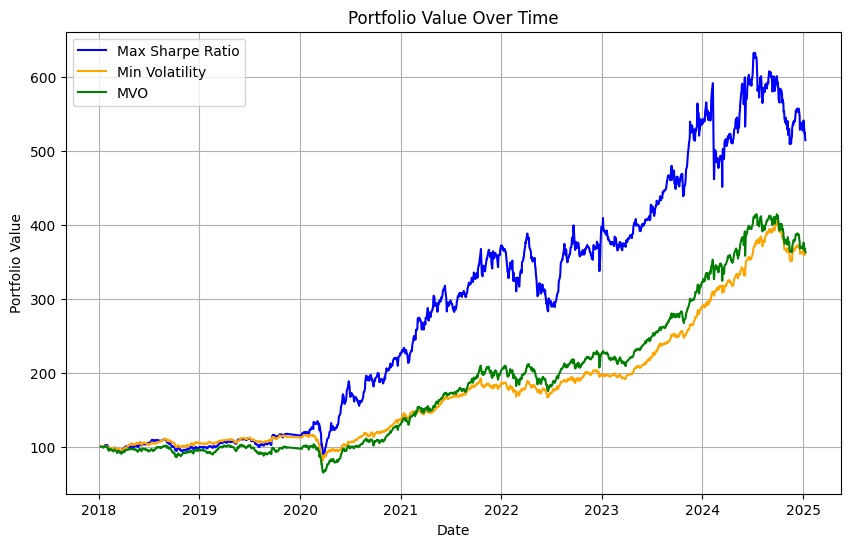

In [137]:
# plot weights history
plt.figure(figsize=(10, 6))
plt.plot(date_series1, final_value1, label='Max Sharpe Ratio', color='blue')
plt.plot(date_series, final_value, label='Min Volatility', color='orange')
plt.plot(date_series2, final_value2, label='MVO', color='green')
plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

In [141]:
# print a dataframe of metrics - sharpe, sortino, max drawdown, volatility, annual return
# like this 

metrics = pd.DataFrame(columns=["Sharpe Ratio", "Sortino Ratio", "Volatility"])
for i, portfolio in enumerate([final_value , final_value1, final_value2]):
   # portfolio_name = ["Nifty 50","BL + MS Portfolio", "BL + MV Portfolio", "Normal EW Portfolio", "Normal MS Portfolio", "Normal MV Portfolio"][i]
    portfolio_name = ["BL + MV Portfolio", "BL + MS Portfolio", "BL+MVO"][i]
    metrics.loc[portfolio_name, "Sharpe Ratio"] = get_sharpe_ratio(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Sortino Ratio"] = get_sortino_ratio(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Volatility"] = get_volatility(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Annualized Returns"] = get_annualized_returns(portfolio)
    metrics.loc[portfolio_name, "Max Drawdown"] = min(get_max_drawdown(pd.Series(portfolio)))


# include nifty 50 portfolio in the metrics dataframe


metrics

,Sharpe Ratio,Sortino Ratio,Volatility,Annualized Returns,Max Drawdown
BL + MV Portfolio,1.070992,1.282744,0.135908,0.210556,-0.306586
BL + MS Portfolio,0.854306,1.023828,0.246243,0.275367,-0.333990
BL+MVO,0.775471,0.895019,0.188317,0.211034,-0.373999


In [60]:
get_sharpe_ratio(pd.Series(final_value))  # Overall Sharpe ratio for the entire period


1.0745255157661475

In [7]:
def backtest_normal(strategy):
    start_date = pd.to_datetime("2018-01-08")
    end_date = pd.to_datetime("2025-01-08")

    initial_investment = 100  # Initial portfolio value
    portfolio_value = [initial_investment]
    dates = [start_date]

    rebalance_frequency = 3
    transaction_cost_rate = 0.004  # 0.4% transaction cost

    W = []                     

    # Backtest loop
    current_date = start_date
    last_rebalance_date = start_date
    previous_weights = None

    # Number of assets (to compute equal weights)
    n_assets = len(assets)
    equal_weight = 1.0 / n_assets  # Equal weight for each asset

    while current_date < end_date:
        S = risk_models.sample_cov(data.loc[:current_date])
        
        # Assign weights based on strategy
        if strategy == "ew":
            cleaned_weights = {stock: equal_weight for stock in assets}
        
        elif strategy == "ms":
            mu = expected_returns.mean_historical_return(data.loc[:current_date])
            cleaned_weights = max_sharpe_ratio(mu, S)
        
        elif strategy == "mv":
            mu = expected_returns.mean_historical_return(data.loc[:current_date])
            cleaned_weights = min_volatility_weights(mu, S)

        elif strategy == "mvo":
            S = risk_models.sample_cov(data.loc[:current_date])
            mu = expected_returns.mean_historical_return(data.loc[:current_date])
            cleaned_weights = MVO(mu, S)
            
        # Check rebalancing conditions
        should_rebalance = False
        days_since_rebalance = (current_date - last_rebalance_date).days
        
        # Condition 1: Every 3 days
        if days_since_rebalance >= rebalance_frequency:
            should_rebalance = True
        
        # Condition 2: Weights change by 60% or more
        if previous_weights is not None:
            weight_diff = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0)) 
                             for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
            if weight_diff >= 0.6:  # 60% threshold
                should_rebalance = True

        if should_rebalance:
            W.append(cleaned_weights)
            
            # Calculate transaction costs
            if previous_weights is not None:
                turnover = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0)) 
                              for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
                transaction_cost = portfolio_value[-1] * turnover * transaction_cost_rate
            else:
                transaction_cost = 0  # No cost on first allocation
            
            previous_weights = cleaned_weights.copy()
            last_rebalance_date = current_date
            
            # Compute portfolio returns for the next rebalance period
            curr_date_index = data.index.get_loc(current_date)
            next_index = min(curr_date_index + rebalance_frequency, len(data) - 1)
            next_date = data.index[next_index]

            # Get actual returns for the rebalance period
            actual_returns = data.loc[current_date:next_date].pct_change().dropna()

            # Ensure cleaned_weights is aligned correctly
            cleaned_weights_series = pd.Series(cleaned_weights)
            
            # Compute portfolio return and apply transaction cost
            portfolio_returns = (actual_returns @ cleaned_weights_series).values

            # Ensure equal length between portfolio_value and dates
            for j in range(len(portfolio_returns)):
                # Calculate new value before transaction cost
                new_value = portfolio_value[-1] * (1 + portfolio_returns[j])
                # Apply transaction cost only on the first day of rebalancing
                if j == 0 and transaction_cost > 0:
                    new_value -= transaction_cost
                portfolio_value.append(new_value)
                dates.append(actual_returns.index[j])  # Append correct date

            # print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
            
            # Move to the next rebalance date
            current_date = next_date
        else:
            # Move forward one day if no rebalancing
            curr_date_index = data.index.get_loc(current_date)
            current_date = data.index[min(curr_date_index + 1, len(data) - 1)]

    # Final portfolio value
    print(f"Final portfolio value: {portfolio_value[-1]}")
    
    return portfolio_value, dates, W




In [63]:
portfolio_value_normal_ew, dates_normal_ew, W_normal_ew = backtest_normal("ew")

Final portfolio value: 339.9800004377008


In [142]:
portfolio_value_normal_ms, dates_normal_ms, W_normal_ms = backtest_normal("ms")

Final portfolio value: 245.29377811536563


In [143]:
portfolio_value_normal_mv, dates_normal_mv, W_normal_mv = backtest_normal("mv")

Final portfolio value: 351.1867342976698


In [ ]:
portfolio_value_normal_mvo, dates_normal_mvo, W_normal_mvo = backtest_normal("mvo")

In [ ]:
# save portfolio_value_normal_mvo
with open('portfolio_value_normal_mvo.pkl', 'wb') as f:
    pickle.dump(portfolio_value_normal_mvo, f)

In [144]:
# save the results
import pickle
with open('portfolio_results_normal_ew.pkl', 'wb') as f:
    pickle.dump((portfolio_value_normal_ew, dates_normal_ew, W_normal_ew), f)

with open('portfolio_results_normal_ms.pkl', 'wb') as f:
    pickle.dump((portfolio_value_normal_ms, dates_normal_ms, W_normal_ms), f)

with open('portfolio_results_normal_mv.pkl', 'wb') as f:
    pickle.dump((portfolio_value_normal_mv, dates_normal_mv, W_normal_mv), f)

In [66]:
get_sharpe_ratio(pd.Series(portfolio_value_normal_ew))  # Overall Sharpe ratio for the entire period

0.7054401175879208

In [80]:
data = pd.read_excel('PX_LAST_Static.xlsx', index_col=0)
data.index = pd.to_datetime(data.index)


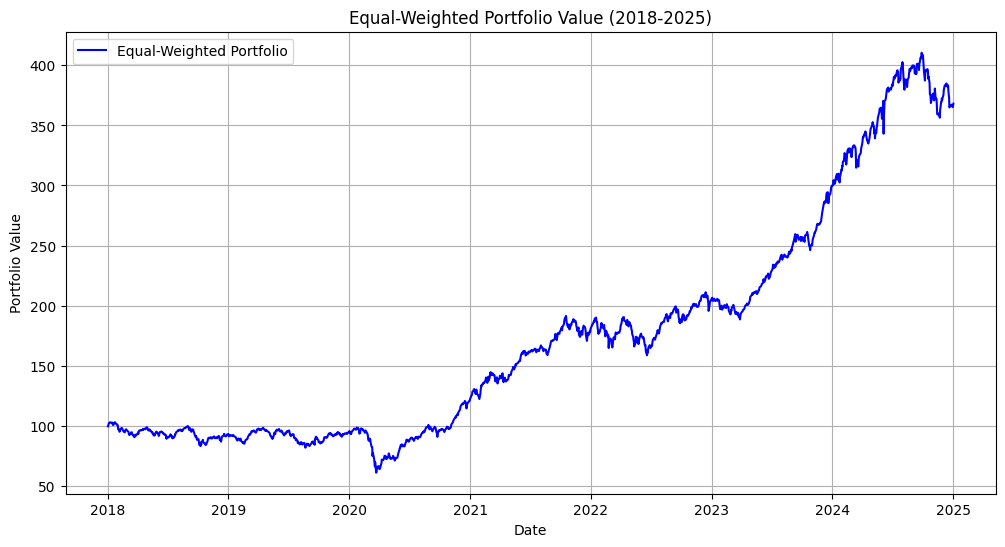

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume 'data' is a DataFrame of closing prices for each asset with a DateTimeIndex.
# For example:
#             AAPL   MSFT   GOOGL  ...
# Date
# 2017-12-29   ...    ...     ...   
# 2018-01-02   ...    ...     ...
# ...
data = pd.read_excel('PX_LAST_Static.xlsx', index_col=0)
data.index = pd.to_datetime(data.index)

# Filter data from 2018 to 2025.
start_date = pd.to_datetime("2018-01-01")
end_date = pd.to_datetime("2025-01-01")
data_subset = data.loc[start_date:end_date]
# data_subset = data.loc["2018-01-01":"2025-12-01"]

# Compute daily returns from the filtered data.
daily_returns = data_subset.pct_change().dropna()

# Determine number of assets and assign equal weight.
n_assets = len(data_subset.columns)
equal_weights = np.full(n_assets, 1/n_assets)

# Compute the portfolio's daily returns as the dot product of asset daily returns and equal weights.
portfolio_daily_returns = daily_returns.dot(equal_weights)

# Set the initial portfolio value, e.g., 100.
initial_investment = 100

# Compute portfolio value over time using a cumulative product.
portfolio_value = initial_investment * (1 + portfolio_daily_returns).cumprod()

# Plot the portfolio value.
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value, label='Equal-Weighted Portfolio', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Equal-Weighted Portfolio Value (2018-2025)')
plt.legend()
plt.grid(True)
plt.show()


In [82]:
# get sharpe ratio for the equal weighted portfolio
get_sharpe_ratio(pd.Series(portfolio_value))  # Overall Sharpe ratio for the entire period

0.7633513853760385

In [ ]:
# import the results

import pickle

with open('portfolio_results.pkl', 'rb') as f:
    portfolio_results = pickle.load(f)

with open('portfolio_results1.pkl', 'rb') as f:
    portfolio_results1 = pickle.load(f)

with open('portfolio_results2.pkl', 'rb') as f:
    portfolio_results2 = pickle.load(f)

with open('portfolio_results_normal_ew.pkl', 'rb') as f:
    portfolio_results_normal_ew = pickle.load(f)

with open('portfolio_results_normal_ms.pkl', 'rb') as f:
    portfolio_results_normal_ms = pickle.load(f)

with open('portfolio_results_normal_mv.pkl', 'rb') as f:
    portfolio_results_normal_mv = pickle.load(f)